# Drug Response Classification

### Task 1: Exploratory Data Analysis (EDA)

##### 1. Load the dataset and perform fundamental data exploration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
df=pd.read_csv(r"C:\Users\tilna\Downloads\Pharma_Industry.csv")

In [3]:
df.shape

(500, 6)

In [4]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [6]:
# missing value
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [7]:
# duplicates
df.duplicated().sum()

np.int64(0)

##### 2. Utilize histograms, box plots, or density plots to understand feature distributions.

<Axes: >

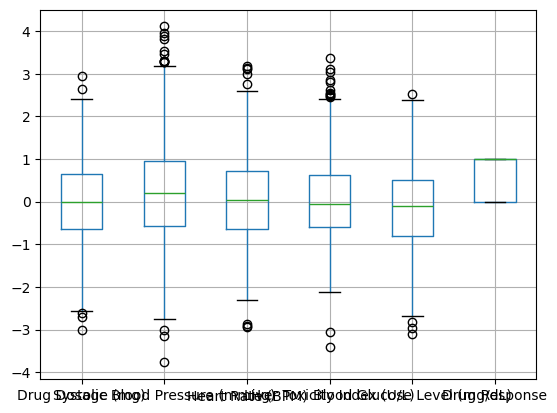

In [8]:
df.boxplot()

In [9]:
# outlier_capping
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    low_ext=Q1-1.5*IQR
    upp_ext=Q3+1.5*IQR
    df[column]=df[column].apply(lambda x: low_ext if x<low_ext else upp_ext if x>upp_ext else x)
for col in df.columns:
    outlier_capping(df,col)

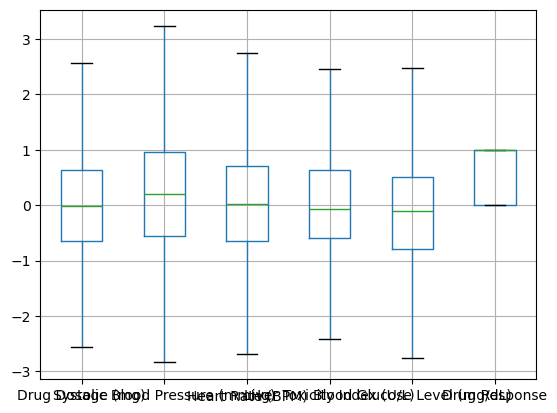

In [10]:
df.boxplot()
plt.show()

##### 3. Investigate feature correlations to discern relationships within the data.

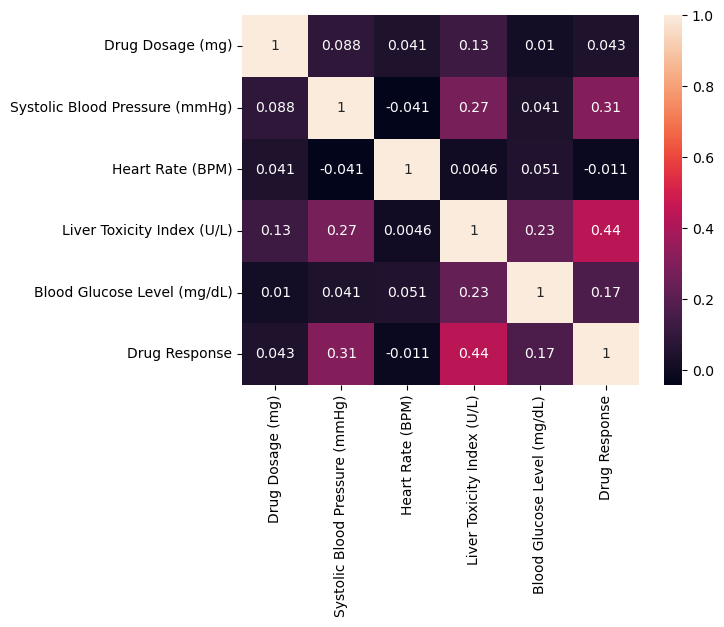

In [11]:
# correlation
corr=df.corr()
sns.heatmap(corr,annot=True)
plt.show()

### Task 2: Data Preprocessing

##### 1. Encode categorical variables if necessary.

##### 2. Split the dataset into training and testing sets.

In [12]:
target=df['Drug Response']
features=df.drop(columns=['Drug Response'])

In [13]:
# train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 5)
(100, 5)
(400,)
(100,)


### Task 3: Data Visualization

##### 1. Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.

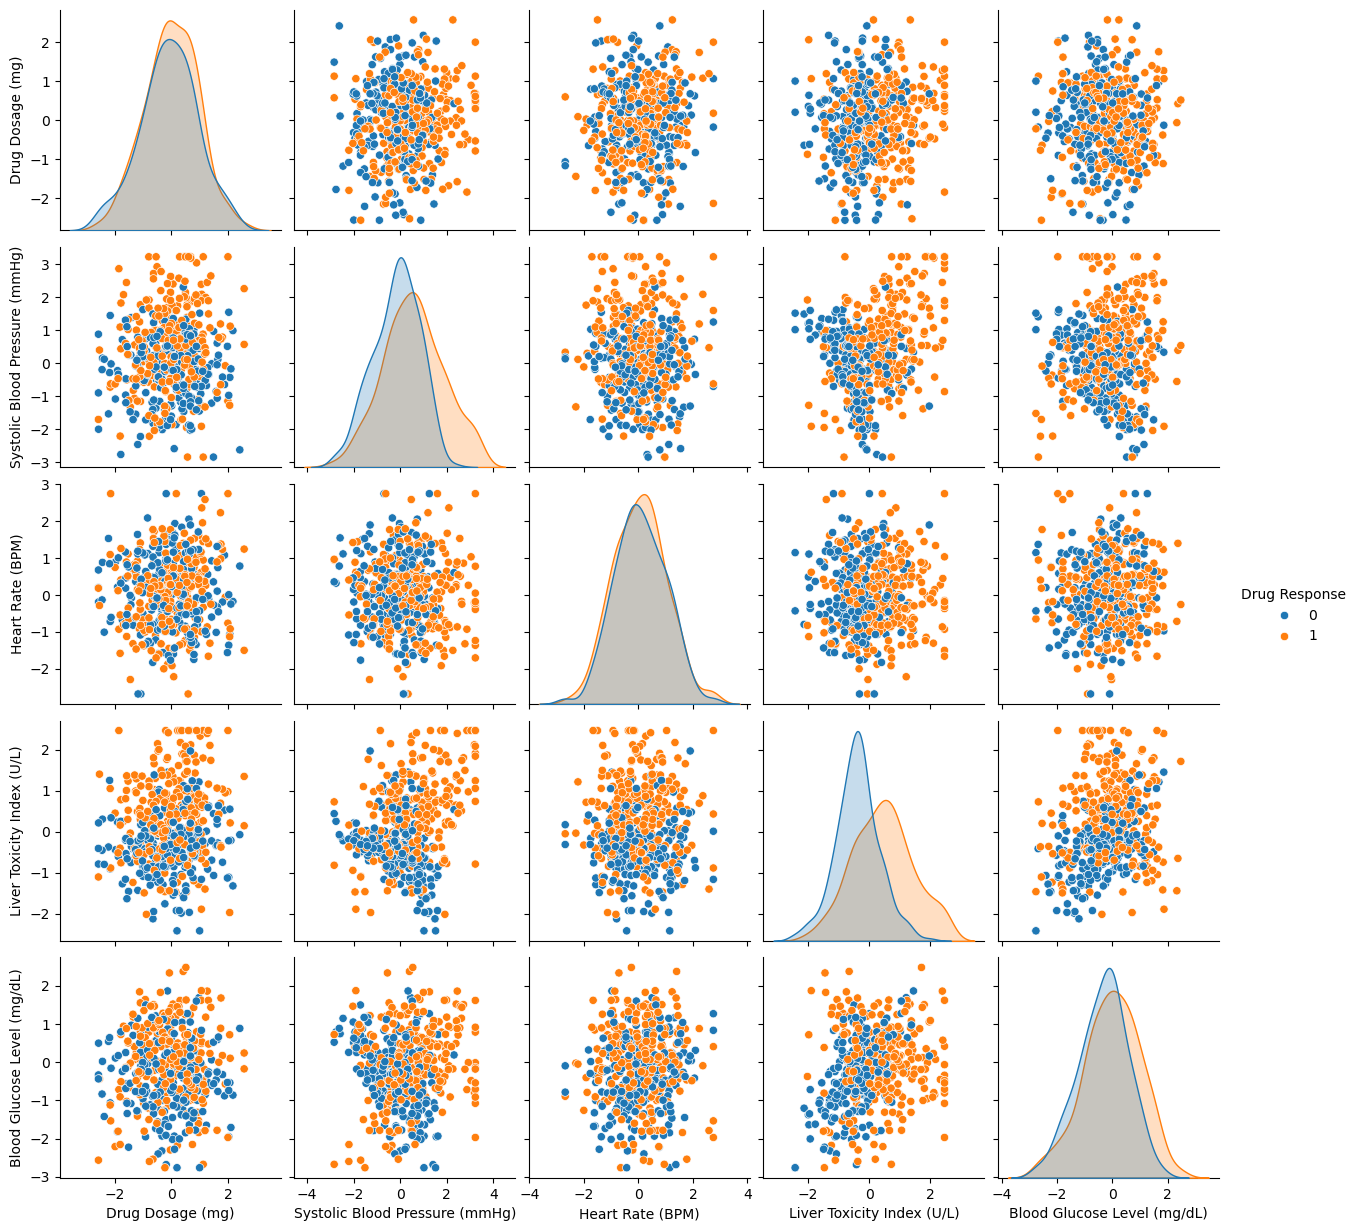

In [14]:
## pairplot
sns.pairplot(df, hue='Drug Response')
plt.show()

##### 2. Visualize class distributions to gauge dataset balance or imbalance.

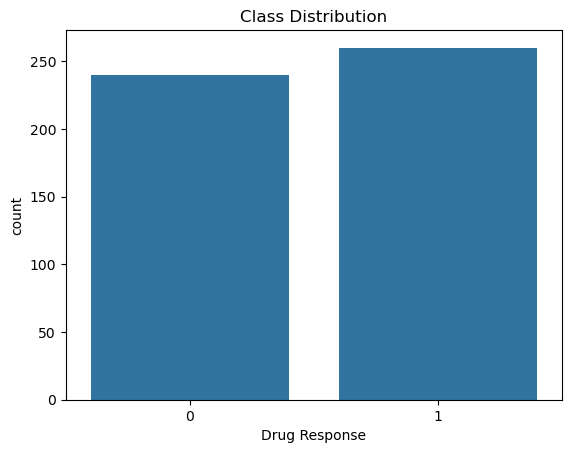

In [15]:
sns.countplot(x=target)
plt.title("Class Distribution")
plt.show()

### Task 4: SVM Implementation

##### 1. Implement a basic SVM classifier using Python libraries like scikit-learn.

In [16]:
# SVC using linear kernal
linear_svc=SVC(kernel='linear',C=1)

##### 2. Train the SVM model on the training data.

In [17]:
linear_svc.fit(x_train,y_train)

SVC(C=1, kernel='linear')

##### 3. Evaluate model performance on the testing data using appropriate metrics (e.g.,accuracy, precision, recall, F1-score).

In [18]:
y_pred=linear_svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.74

### Task 5: Visualization of SVM Results

##### 1. Visualize classification results on the testing data.

In [19]:
### plotting using meshgrid
### slecting Systolic Blood Pressure (mmHg)-x1,Blood Glucose Level (mg/dL)-x2  -- from correlation with target

In [20]:
### plotting using meshgrid
x1_min=df['Systolic Blood Pressure (mmHg)'].min()-1
x1_max=df['Systolic Blood Pressure (mmHg)'].max()+1
x2_min=df['Blood Glucose Level (mg/dL)'].min()-1
x2_max=df['Blood Glucose Level (mg/dL)'].max()+1
print(x1_min,x1_max,x2_min,x2_max)

-3.839982200906558 4.226188669099171 -3.7646201812348314 3.480459563128914


In [21]:
xx,yy=np.meshgrid(np.arange(x1_min,x1_max,0.02),np.arange(x2_min,x2_max,0.02))
print(xx.ndim)
print(yy.ndim)

2
2


In [22]:
x_vis=df[['Systolic Blood Pressure (mmHg)', 'Blood Glucose Level (mg/dL)']]
y_vis=df['Drug Response']
linear_svc_mesh=linear_svc.fit(x_vis,y_vis)

In [23]:
z=np.c_[np.ravel(xx),np.ravel(yy)]
z1=linear_svc.predict(z)
z1.ndim

1

In [24]:
z1=z1.reshape(xx.shape)
z1.ndim

2

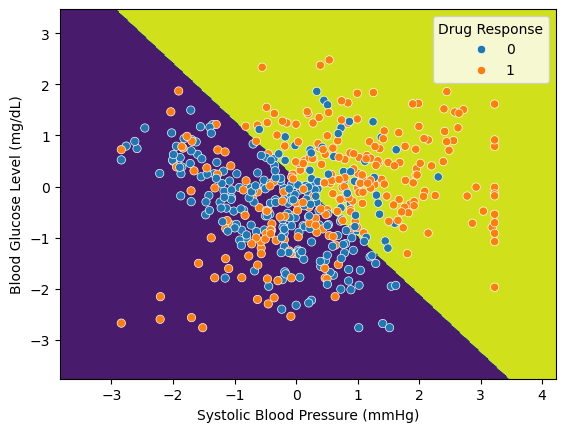

In [25]:
plt.contourf(xx,yy,z1)
sns.scatterplot(data=df,x=df['Systolic Blood Pressure (mmHg)'],y=df['Blood Glucose Level (mg/dL)'],hue=y_vis)
plt.show()

### Task 6: Parameter Tuning and Optimization

##### 1. Experiment with different SVM hyperparameters (e.g., kernel type, regularizationparameter) to optimize performance.

In [26]:
#regularization of poly kernal
params = {'C':[0.1, 1, 10, 100]}
grid_search=GridSearchCV(SVC(kernel='poly'),params,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'C': 1}

In [29]:
# Svc using poly kernal
poly_svc=SVC(kernel='poly',C=1)
poly_svc.fit(x_train,y_train)
y_pred=linear_svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.76

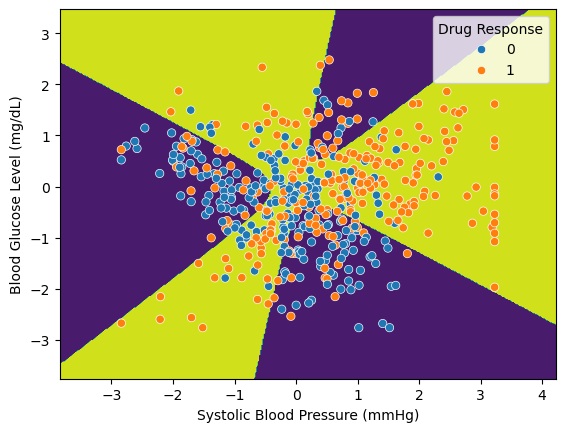

In [36]:
#visualization of poly kernal
poly_svc_mesh=poly_svc.fit(x_vis,y_vis)
z2=poly_svc_mesh.predict(z)
z2=z2.reshape(xx.shape)
plt.contourf(xx,yy,z2)
sns.scatterplot(data=df,x=df['Systolic Blood Pressure (mmHg)'],y=df['Blood Glucose Level (mg/dL)'],hue=y_vis)
plt.show()

In [31]:
#regularization of rbf kernal
params = {'C':[0.1, 1, 10, 100]}
grid_search=GridSearchCV(SVC(kernel='rbf'),params,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'C': 1}

In [32]:
### SVC using rbf kernal
rbf_svc=SVC(kernel='rbf',C=1)
rbf_svc.fit(x_train,y_train)
y_pred=rbf_svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.79

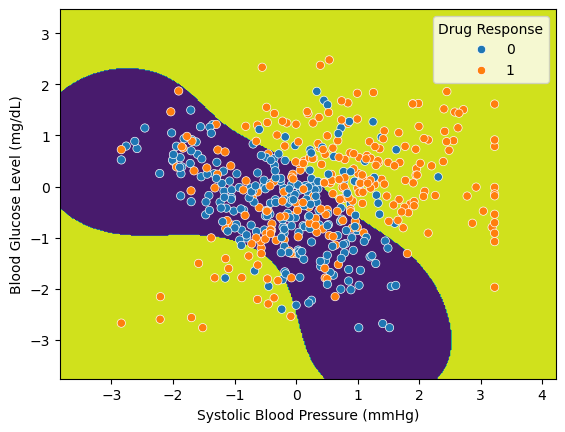

In [37]:
#visualization of rbf kernal
rbf_svc_mesh=rbf_svc.fit(x_vis,y_vis)
z2=rbf_svc_mesh.predict(z)
z2=z2.reshape(xx.shape)
plt.contourf(xx,yy,z2)
sns.scatterplot(data=df,x=df['Systolic Blood Pressure (mmHg)'],y=df['Blood Glucose Level (mg/dL)'],hue=y_vis)
plt.show()

In [40]:
#regularization of sigmoid kernal
params = {'C':[0.1, 1, 10, 100]}
grid_search=GridSearchCV(SVC(kernel='sigmoid'),params,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'C': 0.1}

In [41]:
### SVC using sigmoid kernal
sigmoid_svc=SVC(kernel='sigmoid',C=0.1)
sigmoid_svc.fit(x_train,y_train)
y_pred=sigmoid_svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.73

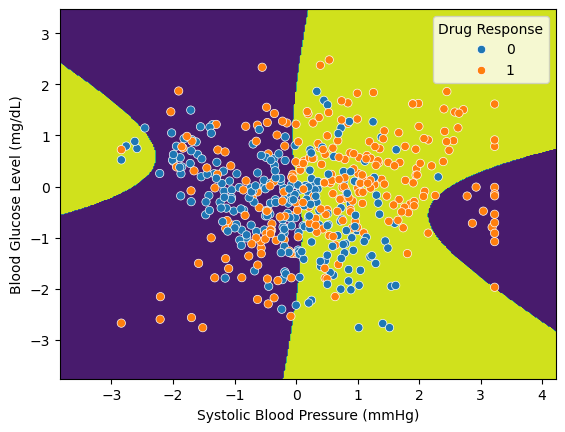

In [38]:
#visualization of sigmoid kernal
sigmoid_svc_mesh=sigmoid_svc.fit(x_vis,y_vis)
z2=sigmoid_svc_mesh.predict(z)
z2=z2.reshape(xx.shape)
plt.contourf(xx,yy,z2)
sns.scatterplot(data=df,x=df['Systolic Blood Pressure (mmHg)'],y=df['Blood Glucose Level (mg/dL)'],hue=y_vis)
plt.show()

### Task 7: Comparison and Analysis

##### 1. Compare SVM performance with various kernels (e.g., linear, polynomial, radial basisfunction).


##### 2. Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.

##### 3. Discuss practical implications of SVM in real-world classification tasks